Fetching Credit Card Fraud dataset from OpenML (this may take a minute)...

--- Class Distribution Analysis ---
Total Transactions: 284807
Normal (0): 284315
Fraud (1): 492
Imbalance Ratio (IR): 577.88 : 1
Percentage of Positives: 0.173%


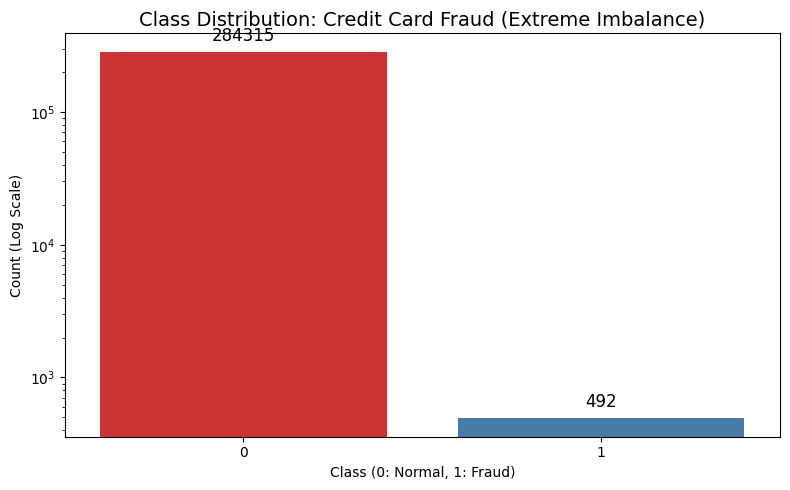

In [1]:
# --- QUESTION 2: CLASSIFICATION & IMBALANCE ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# 1. Ensure Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 2. Load the Credit Card Fraud Dataset from OpenML
print("Fetching Credit Card Fraud dataset from OpenML (this may take a minute)...")
# Using OpenML ID 1597 (Standard Credit Card Fraud Dataset)
credit_data = fetch_openml(data_id=1597, as_frame=True, parser='auto')
df_c = credit_data.frame

# Ensure target is strictly numeric (0: Normal, 1: Fraud)
df_c['Class'] = pd.to_numeric(df_c['Class'])

# 3. Calculate Imbalance Ratio (IR)
positive_class = df_c['Class'].sum()
negative_class = len(df_c) - positive_class
imbalance_ratio = negative_class / positive_class

print("\n--- Class Distribution Analysis ---")
print(f"Total Transactions: {len(df_c)}")
print(f"Normal (0): {negative_class}")
print(f"Fraud (1): {positive_class}")
print(f"Imbalance Ratio (IR): {imbalance_ratio:.2f} : 1")
print(f"Percentage of Positives: {(positive_class/len(df_c))*100:.3f}%")

# 4. Visualise the Imbalance
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_c, x='Class', hue='Class', palette='Set1', legend=False)
plt.title('Class Distribution: Credit Card Fraud (Extreme Imbalance)', fontsize=14)
# We use a log scale on the Y-axis so the tiny fraud bar is actually visible!
plt.yscale('log')
plt.ylabel('Count (Log Scale)')
plt.xlabel('Class (0: Normal, 1: Fraud)')

# Annotate the exact counts above the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

In [2]:
# Install imbalanced-learn just in case
!pip install -q imbalanced-learn

import time
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, matthews_corrcoef, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

print("Setting up Data and Metrics...")

# 1. Prepare Data (Scale the features, which is critical for MLPs and Logistic Regression)
X_raw = df_c.drop('Class', axis=1)
y = df_c['Class']

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# 2. Define our scoring metrics (as requested in the assignment)
scoring = {
    'Precision': make_scorer(precision_score, zero_division=0),
    'Recall': make_scorer(recall_score, zero_division=0),
    'F1_Macro': make_scorer(f1_score, average='macro', zero_division=0),
    'ROC_AUC': make_scorer(roc_auc_score),
    'PR_AUC': make_scorer(average_precision_score),
    'MCC': make_scorer(matthews_corrcoef),
    'Balanced_Acc': make_scorer(balanced_accuracy_score)
}

# Use a Stratified 3-Fold CV to preserve the 0.173% ratio in all splits
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

# 3. Define Cost-Sensitive Classifiers
# Calculate scale_pos_weight for XGBoost (Negative count / Positive count)
spw = len(y[y==0]) / len(y[y==1])

cost_sensitive_models = {
    'LogReg (Cost-Sensitive)': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED),
    'RandomForest (Cost-Sensitive)': RandomForestClassifier(class_weight='balanced', n_estimators=50, max_depth=5, random_state=RANDOM_SEED, n_jobs=-1),
    'XGBoost (Cost-Sensitive)': XGBClassifier(scale_pos_weight=spw, max_depth=3, random_state=RANDOM_SEED, n_jobs=-1),
    # MLP doesn't have a native class_weight, so we will use it as a standard baseline here
    'MLP (Standard)': MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, early_stopping=True, random_state=RANDOM_SEED)
}

# 4. Define Resampling Pipelines (Applied to Logistic Regression for comparison)
# We MUST use imblearn.pipeline to prevent data leakage during Cross Validation!
resampling_pipelines = {
    'LogReg + SMOTE': ImbPipeline([('smote', SMOTE(random_state=RANDOM_SEED)), ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))]),
    'LogReg + ADASYN': ImbPipeline([('adasyn', ADASYN(random_state=RANDOM_SEED)), ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))]),
    'LogReg + Undersampling': ImbPipeline([('rus', RandomUnderSampler(random_state=RANDOM_SEED)), ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))])
}

# Combine dictionaries to run everything in one loop
all_experiments = {**cost_sensitive_models, **resampling_pipelines}
results_list = []

print("\nStarting Cross-Validation (This will take a few minutes...)")
for name, model in all_experiments.items():
    start_time = time.time()
    print(f"Training and Evaluating: {name}...")

    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    time_taken = time.time() - start_time

    results_list.append({
        'Model / Strategy': name,
        'Recall (Fraud)': f"{cv_results['test_Recall'].mean():.4f}",
        'Precision': f"{cv_results['test_Precision'].mean():.4f}",
        'PR-AUC': f"{cv_results['test_PR_AUC'].mean():.4f}",
        'MCC': f"{cv_results['test_MCC'].mean():.4f}",
        'F1 Macro': f"{cv_results['test_F1_Macro'].mean():.4f}",
        'ROC-AUC': f"{cv_results['test_ROC_AUC'].mean():.4f}",
        'Bal. Acc.': f"{cv_results['test_Balanced_Acc'].mean():.4f}",
        'Time (s)': f"{time_taken:.1f}"
    })

# Display the final comparison table
results_df = pd.DataFrame(results_list)
print("\n--- Model Evaluation Results ---")
display(results_df)

Setting up Data and Metrics...

Starting Cross-Validation (This will take a few minutes...)
Training and Evaluating: LogReg (Cost-Sensitive)...
Training and Evaluating: RandomForest (Cost-Sensitive)...
Training and Evaluating: XGBoost (Cost-Sensitive)...
Training and Evaluating: MLP (Standard)...
Training and Evaluating: LogReg + SMOTE...
Training and Evaluating: LogReg + ADASYN...
Training and Evaluating: LogReg + Undersampling...

--- Model Evaluation Results ---


,Model / Strategy,Recall (Fraud),Precision,PR-AUC,MCC,F1 Macro,ROC-AUC,Bal. Acc.,Time (s)
0,LogReg (Cost-Sensitive),0.9085,0.0630,0.0574,0.2357,0.5529,0.9425,0.9425,5.3
1,RandomForest (Cost-Sensitive),0.8516,0.4654,0.3968,0.6284,0.8001,0.9250,0.9250,112.5
2,XGBoost (Cost-Sensitive),0.8537,0.6723,0.5744,0.7571,0.8758,0.9265,0.9265,8.7
3,MLP (Standard),0.7764,0.8924,0.6935,0.8320,0.9149,0.8881,0.8881,26.6
4,LogReg + SMOTE,0.9106,0.0591,0.0539,0.2282,0.5490,0.9427,0.9427,6.3
5,LogReg + ADASYN,0.9329,0.0185,0.0174,0.1247,0.4957,0.9236,0.9236,7.0
6,LogReg + Undersampling,0.9187,0.0424,0.0391,0.1932,0.5314,0.9414,0.9414,0.6


Starting Calibration and Final Evaluations...

Processing XGBoost (Cost-Sensitive)...
Calibrating XGBoost (Cost-Sensitive) using Isotonic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Brier Score (Uncalibrated): 0.0011
Brier Score (Calibrated):   0.0005

Processing MLP (Standard)...
Calibrating MLP (Standard) using Isotonic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Brier Score (Uncalibrated): 0.0005
Brier Score (Calibrated):   0.0006


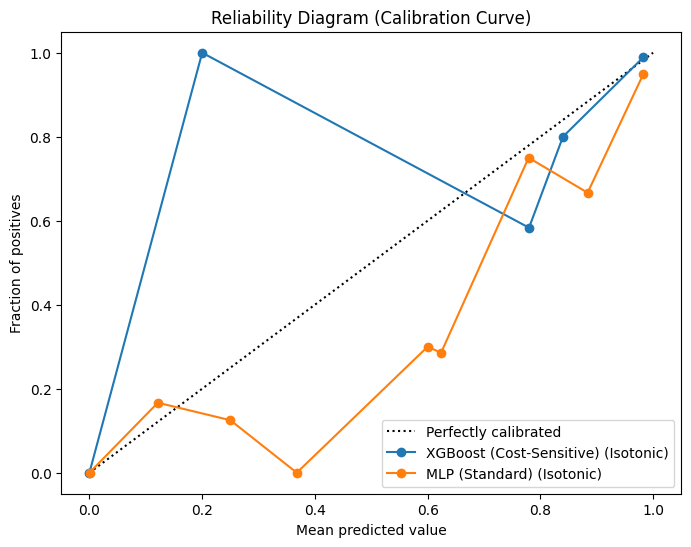

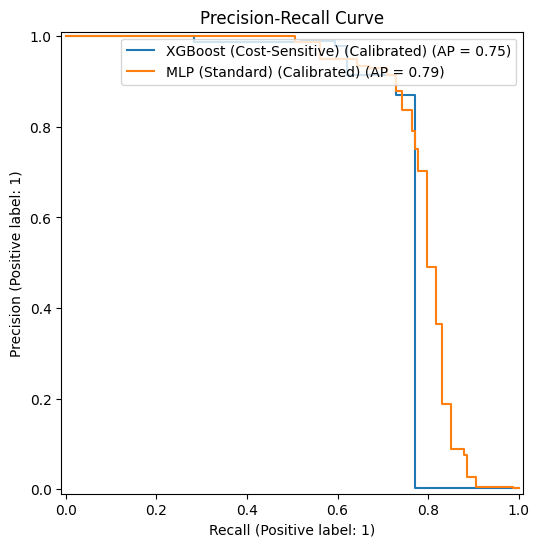

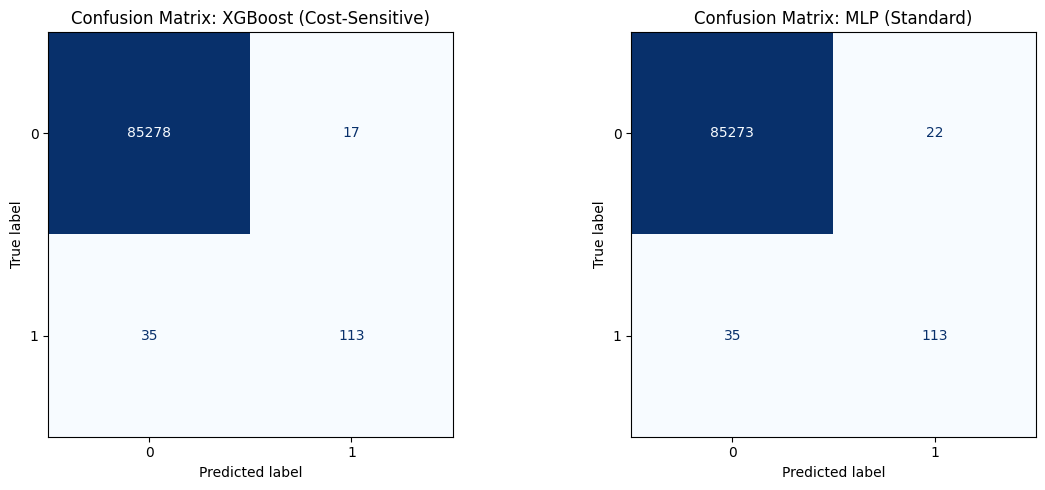

In [3]:
# 5. Probability Calibration, PR Curves, and Confusion Matrices
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, PrecisionRecallDisplay, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("Starting Calibration and Final Evaluations...")

# Split data for this specific task (Calibration needs a separate validation set ideally,
# but for this assignment, a standard train/test split will suffice to generate the plots)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

# Define our two best models
best_models = {
    'XGBoost (Cost-Sensitive)': XGBClassifier(scale_pos_weight=spw, max_depth=3, random_state=RANDOM_SEED, n_jobs=-1),
    'MLP (Standard)': MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, early_stopping=True, random_state=RANDOM_SEED)
}

fig_calib, ax_calib = plt.subplots(figsize=(8, 6))
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
confusion_axes = []
fig_cm, axes_cm = plt.subplots(1, 2, figsize=(12, 5))

# Plot perfectly calibrated reference line
ax_calib.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

for idx, (name, model) in enumerate(best_models.items()):
    print(f"\nProcessing {name}...")

    # Fit the uncalibrated model first
    model.fit(X_train, y_train)
    y_prob_uncalib = model.predict_proba(X_test)[:, 1]

    # Calibrate using Isotonic Regression
    print(f"Calibrating {name} using Isotonic Regression...")
    calibrated_clf = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
    calibrated_clf.fit(X_train, y_train) # Note: In strict practice, fit this on a separate validation set
    y_prob_calib = calibrated_clf.predict_proba(X_test)[:, 1]
    y_pred_calib = calibrated_clf.predict(X_test)

    # 1. Brier Score (Lower is better)
    brier_uncalib = brier_score_loss(y_test, y_prob_uncalib)
    brier_calib = brier_score_loss(y_test, y_prob_calib)
    print(f"Brier Score (Uncalibrated): {brier_uncalib:.4f}")
    print(f"Brier Score (Calibrated):   {brier_calib:.4f}")

    # 2. Reliability Diagrams (Calibration Curves)
    prob_true, prob_pred = calibration_curve(y_test, y_prob_calib, n_bins=10)
    ax_calib.plot(prob_pred, prob_true, marker='o', label=f"{name} (Isotonic)")

    # 3. Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(y_test, y_prob_calib, name=f"{name} (Calibrated)", ax=ax_pr)

    # 4. Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_calib, ax=axes_cm[idx], cmap='Blues', colorbar=False)
    axes_cm[idx].set_title(f"Confusion Matrix: {name}")

# Format Calibration Plot
ax_calib.set_ylabel("Fraction of positives")
ax_calib.set_xlabel("Mean predicted value")
ax_calib.set_title("Reliability Diagram (Calibration Curve)")
ax_calib.legend(loc="lower right")

# Format PR Plot
ax_pr.set_title("Precision-Recall Curve")
ax_pr.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Show PR Curve separately to avoid overlap
fig_pr.tight_layout()
plt.show()